In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
FIGURE_DIR = "../output/figures/descriptives"
TABLE_DIR = "../output/tables"
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

def save_figure(filename_stem, directory=FIGURE_DIR):
    """Save the current matplotlib figure as pdf, png and svg."""
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

In [3]:
df_raw = pd.read_pickle("../output/data/merged_analysis_data.pkl")
df_standardized = pd.read_pickle("../output/data/merged_analysis_data_standardized.pkl")

In [4]:
# restrict the raw data to the same raster_ids as the standardized
common_raster_ids = df_standardized['raster_id']
n_before = len(df_raw)
df_raw = df_raw[df_raw['raster_id'].isin(common_raster_ids)].copy()

In [5]:
# The 9 continuous variables
variables = [
    'work_abs_diff', 'loc_work_gaussian_opening', 'productivity', 'n_companies',
    'entropy', 'distance_to_deak', 'income_entr_open', 'sex_fem_ratio_open', 'arpu_high_ratio_open'
]

variable_labels = {
    'work_abs_diff': 'Workplace dependence',
    'loc_work_gaussian_opening': 'Work activity',
    'productivity': 'Productivity',
    'n_companies': 'Number of companies',
    'entropy': 'Industry entropy',
    'distance_to_deak': 'Distance to centre',
    'income_entr_open': 'Income entropy',
    'sex_fem_ratio_open': 'Ratio of women',
    'arpu_high_ratio_open': 'Ratio of high income',
}

# Summary statistics table

In [6]:
def compute_summary_table(df, variables, labels):
    """N, mean, SD, min, quartiles (25th/50th/75th) and max for each variable."""
    rows = []
    for var in variables:
        series = df[var]
        rows.append({
            'Variable': labels.get(var, var),
            'N': len(df),
            'Mean': series.mean(),
            'SD': series.std(),
            'Min': series.min(),
            'P25': series.quantile(0.25),
            'Median': series.quantile(0.50),
            'P75': series.quantile(0.75),
            'Max': series.max(),
        })
    table = pd.DataFrame(rows).set_index('Variable')
    numeric_cols = table.columns.drop('N')
    table[numeric_cols] = table[numeric_cols].round(2)
    return table

In [7]:
summary_raw = compute_summary_table(df_raw, variables, variable_labels)
print("=== Absolute values ===")
print(summary_raw.to_string())

summary_standardized = compute_summary_table(df_standardized, variables, variable_labels)
print("\n=== Standardized ===")
print(summary_standardized.to_string())

=== Absolute values ===
                         N      Mean        SD    Min      P25    Median       P75         Max
Variable                                                                                      
Workplace dependence  8861     -0.68      3.95 -36.93    -1.47      0.11      1.08       13.66
Work activity         8861     15.52     18.75   1.02     2.77      8.03     20.42      156.46
Productivity          8861  30360.63  58963.05   0.00  9284.93  17741.44  33673.29  1826233.83
Number of companies   8861      3.31      5.91   1.00     1.00      2.00      3.00      143.00
Industry entropy      8861      0.92      1.11   0.00     0.00      0.92      1.58        5.95
Distance to centre    8861   7565.89   3952.62  56.35  4502.24   7462.98  10080.04    20648.82
Income entropy        8861      0.98      0.22   0.00     0.90      0.99      1.08        1.58
Ratio of women        8861      0.30      0.04   0.10     0.27      0.30      0.32        0.49
Ratio of high income  8861

In [ ]:
# Save both as LaTeX tables 
summary_raw.to_latex(
    f"{TABLE_DIR}/summary_stats_raw.tex",
    float_format="%.3f",
    caption="Descriptive statistics (absolute value)",
    label="tab:summary_stats_absolute",
)

summary_standardized.to_latex(
    f"{TABLE_DIR}/summary_stats_standardized.tex",
    float_format="%.3f",
    caption="Descriptive statistics (standardized)",
    label="tab:summary_stats_standardized",
)

# Distributions

In [9]:
def plot_distribution(df, var, label, ax=None, color="#447fdd"):
    """Histogram + KDE for one variable, annotated with mean/median lines."""
    series = df[var].dropna()

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 4))

    sns.histplot(series, kde=True, ax=ax, color=color, edgecolor="white", alpha=0.7)

    ax.axvline(series.mean(), color="black", linestyle="--", linewidth=1.5, label="Mean")
    ax.axvline(series.median(), color="gray", linestyle=":", linewidth=1.5, label="Median")

    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count" if standalone else "")

    if standalone:
        ax.legend(frameon=False, fontsize=9)
        plt.tight_layout()

    return ax

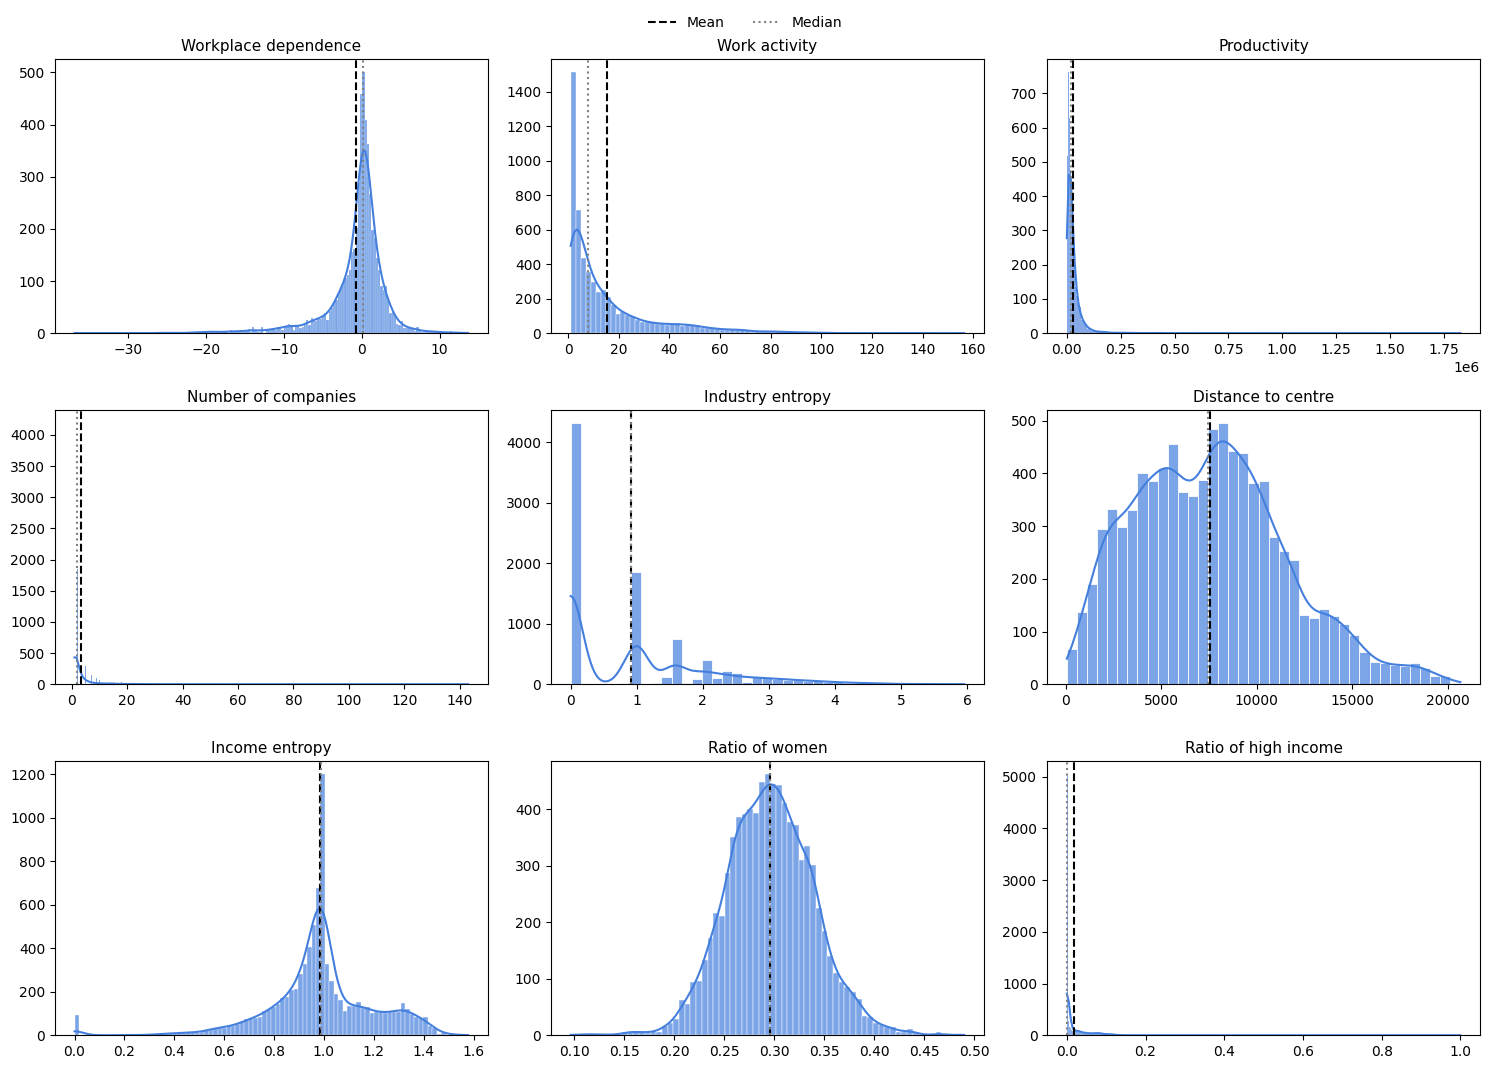

In [10]:
# Combined overview grid - all 9 variables in one figure
n_vars = len(variables)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    plot_distribution(df_raw, var, variable_labels.get(var, var), ax=axes[i])

# Hide any unused subplot axes (if n_vars doesn't fill the grid exactly)
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

# Single shared legend for the whole grid
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
save_figure("variable_distributions_grid")
plt.show()

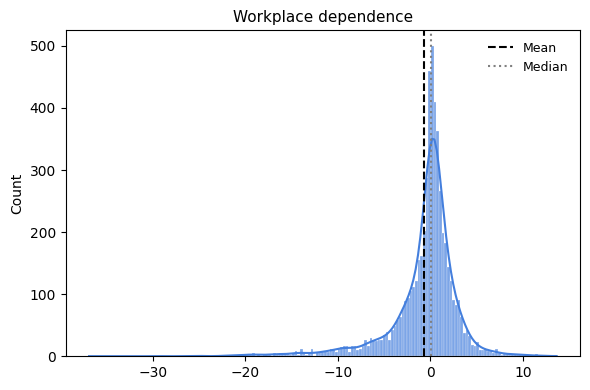

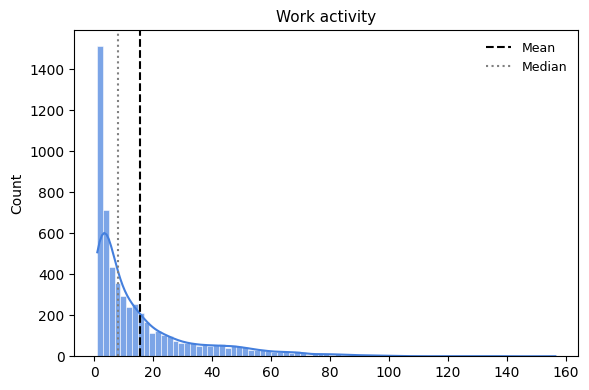

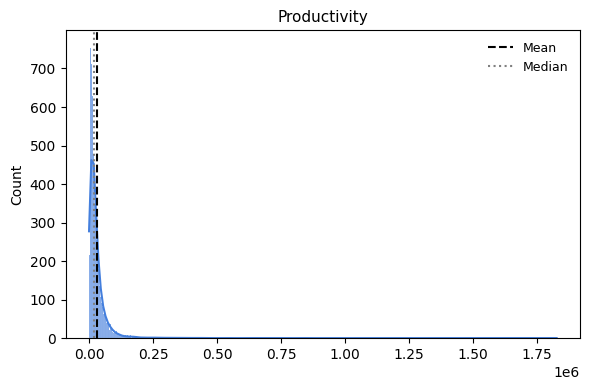

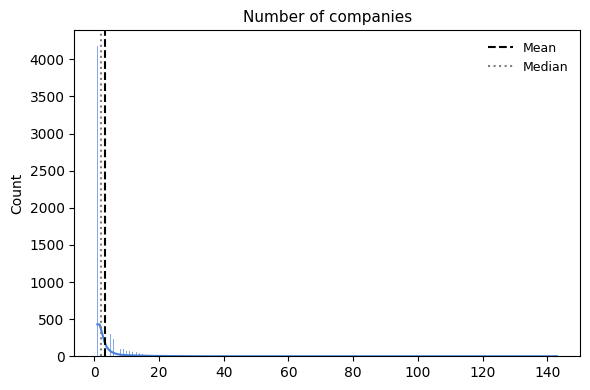

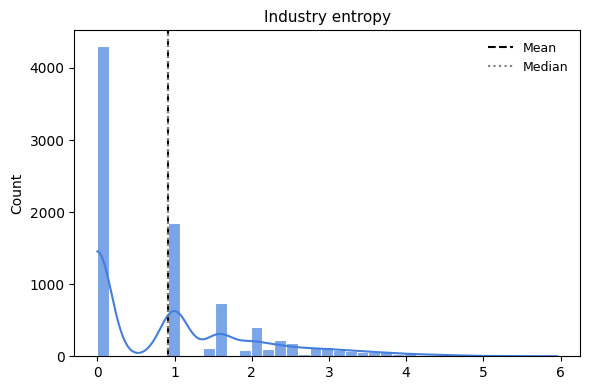

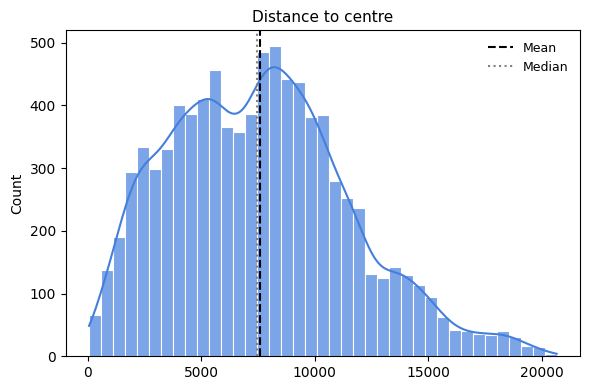

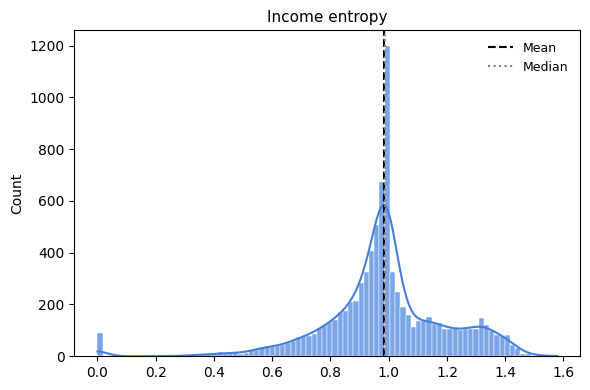

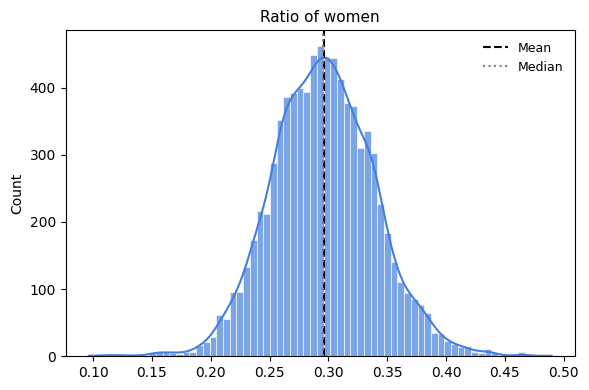

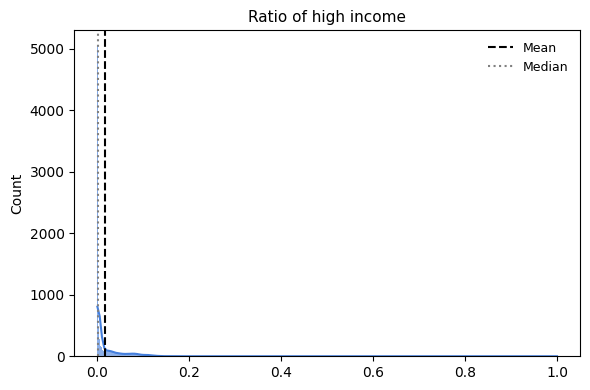

In [11]:
# Individual per-variable plots
for var in variables:
    plot_distribution(df_raw, var, variable_labels.get(var, var))
    plt.legend(frameon=False, fontsize=9)
    save_figure(f"distribution_{var}")
    plt.show()